In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

data = pd.read_csv('c:/Users/USER/Downloads/SanYi_training.csv')

# 處理缺失值（用中位數補齊）
data.fillna(data.median(), inplace=True)

# 特徵與目標分離
X = data.drop(columns=['PM25'])
y = data['PM25']

# 分割資料集為訓練集與測試集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 建立決策樹模型
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

# 模型預測
y_pred = model.predict(X_test)

# 評估模型
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.2f}")


Mean Squared Error: 271.78
R² Score: 0.24


c:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_k

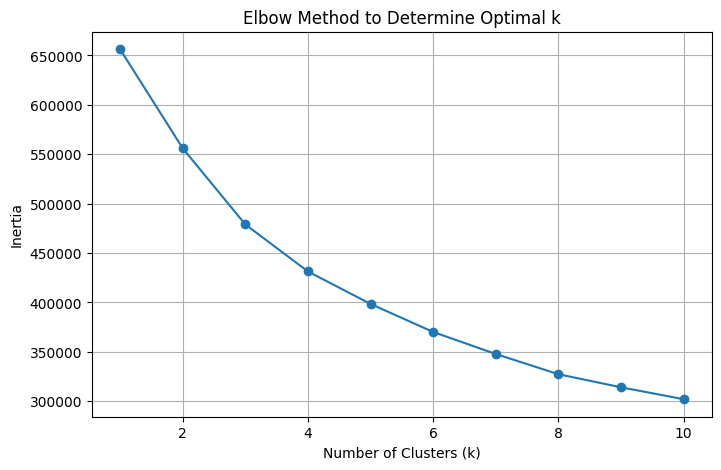

In [2]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. 數據標準化處理
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# 2. 確定最佳的群數 k (使用肘部法則)
inertia = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_scaled)
    inertia.append(kmeans.inertia_)

# 繪製肘部法則圖
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method to Determine Optimal k')
plt.grid()
plt.show()


c:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_k

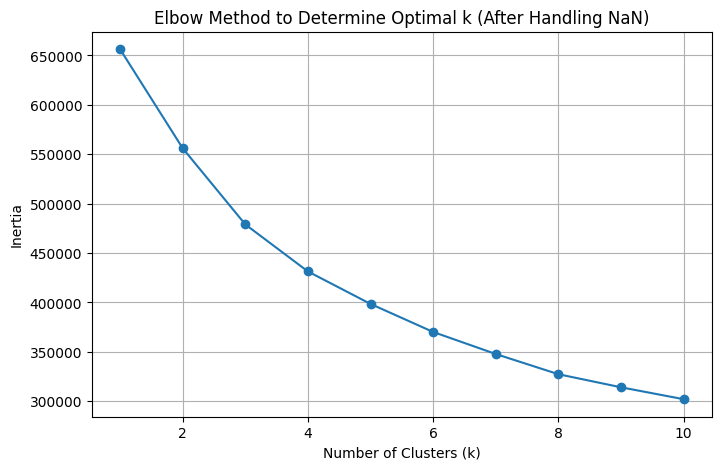

In [3]:
# 填補缺失值（使用列的平均值）
data_filled = data.fillna(data.mean())

# 再次進行數據標準化處理
data_scaled = scaler.fit_transform(data_filled)

# 重新計算肘部法則
inertia = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_scaled)
    inertia.append(kmeans.inertia_)

# 繪製肘部法則圖
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method to Determine Optimal k (After Handling NaN)')
plt.grid()
plt.show()


c:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


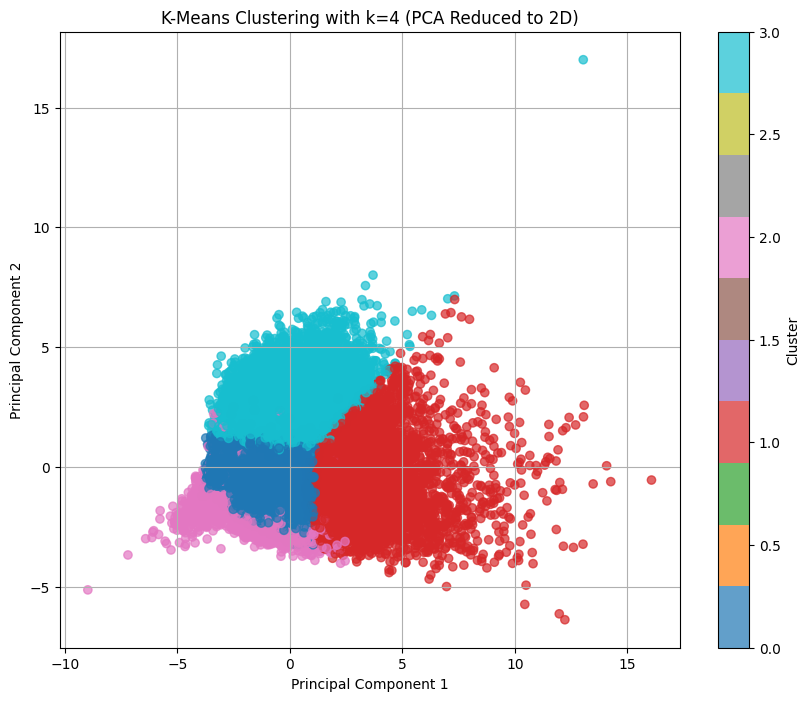

Cluster
0    22199
3     9831
1     9230
2     2492
Name: count, dtype: int64

In [4]:
# 重新導入所需的資料和步驟，確保數據處理的完整性
import pandas as pd
data = pd.read_csv('c:/Users/USER/Downloads/SanYi_training.csv')

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 處理缺失值（使用列的平均值）
data_filled = data.fillna(data.mean())

# 標準化數據
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_filled)

# 使用 K-Means 分群，k=4
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(data_scaled)

# 將分群結果加入原數據
data_filled['Cluster'] = clusters

# 使用 PCA 降到 2D 空間以視覺化分群結果
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_scaled)

plt.figure(figsize=(10, 8))
plt.scatter(data_pca[:, 0], data_pca[:, 1], c=clusters, cmap='tab10', alpha=0.7)
plt.colorbar(label='Cluster')
plt.title(f'K-Means Clustering with k=4 (PCA Reduced to 2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid()
plt.show()

# 顯示每個群的大小
data_filled['Cluster'].value_counts()


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score


# 分群結果作為目標變數（y），其餘變數作為特徵（X）
X = data_filled.drop(columns=['Cluster'])
y = data_filled['Cluster']

# 分割數據集為訓練集和測試集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 訓練 Logistic Regression 模型
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train, y_train)

# 模型評估
y_pred = logistic_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

# 輸出結果
print(f"Logistic Regression Model Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Logistic Regression Model Accuracy: 0.9788

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      6698
           1       0.96      0.97      0.96      2752
           2       0.98      0.98      0.98       753
           3       0.98      0.98      0.98      2923

    accuracy                           0.98     13126
   macro avg       0.98      0.98      0.98     13126
weighted avg       0.98      0.98      0.98     13126



c:\Users\USER\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


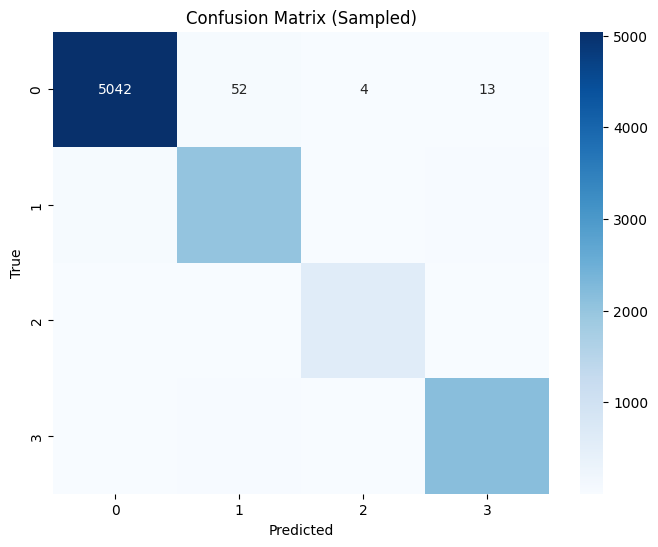

In [6]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
# 減少測試集規模
sample_size = 10000  # 固定取 10,000 條樣本
X_sample = X_test.sample(n=sample_size, random_state=42)
y_sample = y_test.sample(n=sample_size, random_state=42)

# 預測
y_pred_sample = logistic_model.predict(X_sample)

# 計算混淆矩陣
cm = confusion_matrix(y_sample, y_pred_sample)

# 繪製混淆矩陣
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Sampled)')
plt.show()

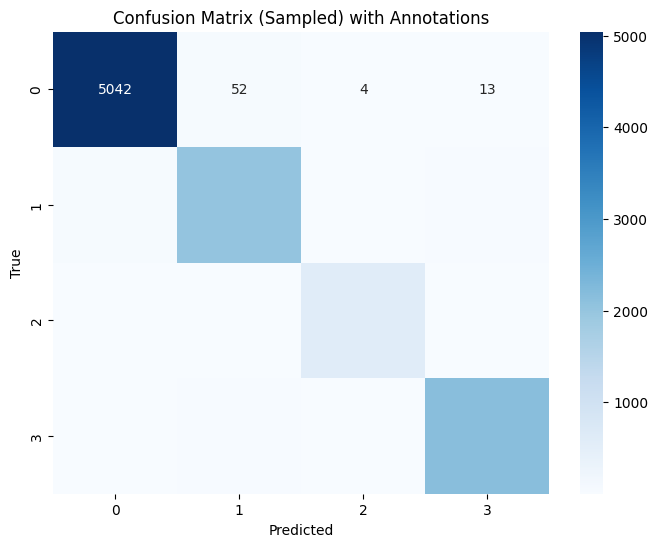

NameError: name 'np' is not defined

In [7]:
# 重新繪製混淆矩陣，添加每個方格的數字標籤
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')  # 添加數字標籤
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Sampled) with Annotations')
plt.show()
# 計算模型的總正確率 (Accuracy)
total_correct = np.trace(cm)  # 混淆矩陣對角線上的值之和
total_samples = np.sum(cm)    # 混淆矩陣中所有值之和
accuracy = total_correct / total_samples

# 輸出準確率
print(f"Model Accuracy: {accuracy:.4f}")


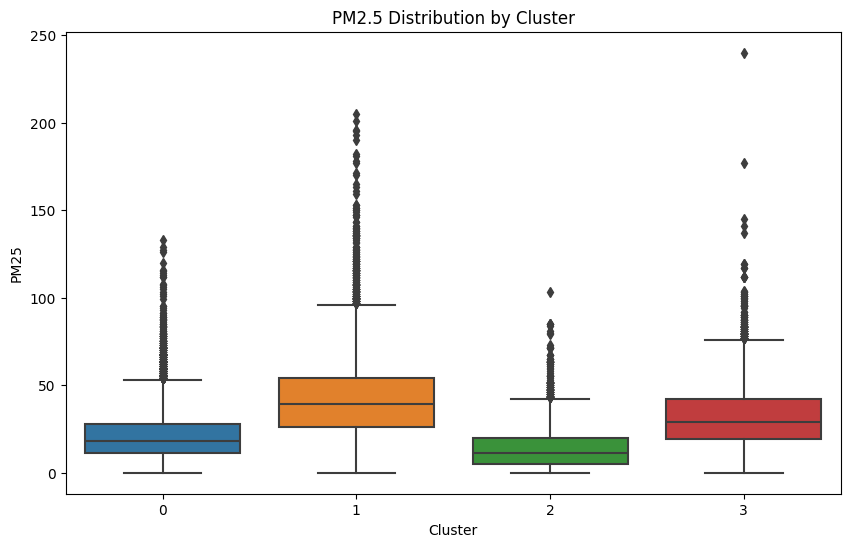

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# 比較 PM2.5 在不同群集中的分佈
plt.figure(figsize=(10, 6))
sns.boxplot(x='Cluster', y='PM25', data=data_filled)
plt.title('PM2.5 Distribution by Cluster')
plt.show()
